In [5]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('nutrabay.csv')

In [7]:
df.head(50)

,Product,Price
0,Nutrabay Gold Pea Protein,"₹1,499"
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...","₹3,149"
2,Nutrabay Yeast Protein,"₹1,999"
3,Nutrabay Gold Whey Protein Concentrate,"₹2,799"
4,Nutrabay Pure Pea Protein Isolate,"₹1,099"
5,Nutrabay Pure Whey Protein Concentrate,"₹2,599"
6,Nutrabay Pure Whey Protein Isolate,"₹4,499"
7,Nutrabay Gold Whey Protein Isolate,"₹4,499"
8,Nutrabay Gold Tri-Blend Whey Protein,"₹3,299"
9,Nutrabay Wellness Vegan Plant Protein Powder +...,"₹1,889"


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Product  43 non-null     str  
 1   Price    43 non-null     str  
dtypes: str(2)
memory usage: 2.9 KB


In [9]:
df.describe()

,Product,Price
count,43,43
unique,43,37
top,Nutrabay Gold Pea Protein,"₹1,099"
freq,1,2


In [10]:
df.isnull().sum()

Product    0
Price      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Price"] = df["Price"].str.replace('₹','')
df["Price"] = df["Price"].str.replace(',','')

In [13]:
df.head()

,Product,Price
0,Nutrabay Gold Pea Protein,1499
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149
2,Nutrabay Yeast Protein,1999
3,Nutrabay Gold Whey Protein Concentrate,2799
4,Nutrabay Pure Pea Protein Isolate,1099


In [14]:
df["Price"] = df["Price"].astype(int)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Product  43 non-null     str  
 1   Price    43 non-null     int64
dtypes: int64(1), str(1)
memory usage: 2.6 KB


In [16]:
def category(x):
    
    x = x.lower()
    
    if 'whey' in x:
        return 'Whey Protein'
    
    elif 'pea' in x:
        return 'Pea Protein'
    
    elif 'yeast' in x:
        return 'Yeast Protein'
    
    elif 'creatine' in x:
        return 'Creatine'
    
    elif 'oats' in x:
        return 'Healthy Oats'
    
    elif 'omega' in x or 'fish oil' in x:
        return 'Omega 3'
    
    elif 'mass gainer' in x or 'gainer' in x:
        return 'Mass Gainer'
    
    elif 'multivitamin' in x:
        return 'Multivitamin'
    
    elif 'magnesium' in x:
        return 'Mineral Supplement'
    
    else:
        return 'Other'

df['Category'] = df['Product'].apply(category)

In [17]:
df.head(50)

,Product,Price,Category
0,Nutrabay Gold Pea Protein,1499,Pea Protein
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149,Whey Protein
2,Nutrabay Yeast Protein,1999,Yeast Protein
3,Nutrabay Gold Whey Protein Concentrate,2799,Whey Protein
4,Nutrabay Pure Pea Protein Isolate,1099,Pea Protein
5,Nutrabay Pure Whey Protein Concentrate,2599,Whey Protein
6,Nutrabay Pure Whey Protein Isolate,4499,Whey Protein
7,Nutrabay Gold Whey Protein Isolate,4499,Whey Protein
8,Nutrabay Gold Tri-Blend Whey Protein,3299,Whey Protein
9,Nutrabay Wellness Vegan Plant Protein Powder +...,1889,Other


In [18]:
df['Category'].value_counts()

Category
Whey Protein          11
Creatine              11
Omega 3                7
Healthy Oats           5
Pea Protein            3
Other                  2
Yeast Protein          1
Mineral Supplement     1
Multivitamin           1
Mass Gainer            1
Name: count, dtype: int64

In [19]:
df.groupby('Category')['Price'].mean()

Category
Creatine               827.363636
Healthy Oats           490.200000
Mass Gainer           1199.000000
Mineral Supplement     741.000000
Multivitamin           699.000000
Omega 3                628.857143
Other                 1124.000000
Pea Protein           1265.666667
Whey Protein          3885.363636
Yeast Protein         1999.000000
Name: Price, dtype: float64

In [20]:
df.sort_values(by='Price',ascending = False).head(60)

,Product,Price,Category
27,MuscleTech NitroTech Whey Gold,6999,Whey Protein
26,Kevin Levrone Anabolic Iso Whey,6699,Whey Protein
6,Nutrabay Pure Whey Protein Isolate,4499,Whey Protein
7,Nutrabay Gold Whey Protein Isolate,4499,Whey Protein
38,Nakpro Nutrition Platinum Whey Protein Isolate...,3499,Whey Protein
8,Nutrabay Gold Tri-Blend Whey Protein,3299,Whey Protein
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149,Whey Protein
3,Nutrabay Gold Whey Protein Concentrate,2799,Whey Protein
5,Nutrabay Pure Whey Protein Concentrate,2599,Whey Protein
42,Nakpro Nutrition Hydro Whey Protein Hydrolyzed...,2399,Whey Protein


In [21]:
def supplement(x):
    
    x = x.lower()

    if 'nutrabay' in x:
        return 'Nutrabay Product'
    
    elif 'muscletech' in x:
        return 'MuscleTech Product'

    elif 'kevin levrone' in x:
        return 'Kevin Levrone Product'

    elif 'gnc' in x:
        return 'GNC Product'

    elif 'nakpro' in x:
        return 'Nakpro Product'

    elif 'isopure' in x:
        return 'Isopure Product'
    
    elif 'labrada' in x:
        return 'Labrada Product'
    
    elif 'muscleblaze' in x:
        return 'MuscleBlaze Product'
    
    elif 'wellcore' in x:
        return 'Wellcore Product'

    elif 'optimum nutrition' in x or '(on)' in x:
        return 'Optimum Nutrition Product'

    elif 'pintola' in x:
        return 'Pintola Product'

    elif "doctor's choice" in x:
        return "Doctor's Choice Product"

    else:
        return 'Other'

df['Supplement'] = df['Product'].apply(supplement)

In [22]:
df.head(50)

,Product,Price,Category,Supplement
0,Nutrabay Gold Pea Protein,1499,Pea Protein,Nutrabay Product
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149,Whey Protein,Nutrabay Product
2,Nutrabay Yeast Protein,1999,Yeast Protein,Nutrabay Product
3,Nutrabay Gold Whey Protein Concentrate,2799,Whey Protein,Nutrabay Product
4,Nutrabay Pure Pea Protein Isolate,1099,Pea Protein,Nutrabay Product
5,Nutrabay Pure Whey Protein Concentrate,2599,Whey Protein,Nutrabay Product
6,Nutrabay Pure Whey Protein Isolate,4499,Whey Protein,Nutrabay Product
7,Nutrabay Gold Whey Protein Isolate,4499,Whey Protein,Nutrabay Product
8,Nutrabay Gold Tri-Blend Whey Protein,3299,Whey Protein,Nutrabay Product
9,Nutrabay Wellness Vegan Plant Protein Powder +...,1889,Other,Nutrabay Product


In [23]:
df.sort_values(by='Price' , ascending=False)


,Product,Price,Category,Supplement
27,MuscleTech NitroTech Whey Gold,6999,Whey Protein,MuscleTech Product
26,Kevin Levrone Anabolic Iso Whey,6699,Whey Protein,Kevin Levrone Product
6,Nutrabay Pure Whey Protein Isolate,4499,Whey Protein,Nutrabay Product
7,Nutrabay Gold Whey Protein Isolate,4499,Whey Protein,Nutrabay Product
38,Nakpro Nutrition Platinum Whey Protein Isolate...,3499,Whey Protein,Nakpro Product
8,Nutrabay Gold Tri-Blend Whey Protein,3299,Whey Protein,Nutrabay Product
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149,Whey Protein,Nutrabay Product
3,Nutrabay Gold Whey Protein Concentrate,2799,Whey Protein,Nutrabay Product
5,Nutrabay Pure Whey Protein Concentrate,2599,Whey Protein,Nutrabay Product
42,Nakpro Nutrition Hydro Whey Protein Hydrolyzed...,2399,Whey Protein,Nakpro Product


In [24]:
def protein_grams(x):
    
    x = x.lower()
    
    if 'whey' in x:
        return 24
    
    elif 'pea' in x:
        return 25
    
    elif 'yeast' in x:
        return 22
    
    elif 'oats' in x:
        return 12
    
    elif 'mass gainer' in x:
        return 30
    
    else:
        return 0

df['Protein_grams'] = df['Product'].apply(protein_grams)

In [25]:
df.head(40)

,Product,Price,Category,Supplement,Protein_grams
0,Nutrabay Gold Pea Protein,1499,Pea Protein,Nutrabay Product,25
1,"Nutrabay BioAbsorb™ Whey Protein Powder, 26g P...",3149,Whey Protein,Nutrabay Product,24
2,Nutrabay Yeast Protein,1999,Yeast Protein,Nutrabay Product,22
3,Nutrabay Gold Whey Protein Concentrate,2799,Whey Protein,Nutrabay Product,24
4,Nutrabay Pure Pea Protein Isolate,1099,Pea Protein,Nutrabay Product,25
5,Nutrabay Pure Whey Protein Concentrate,2599,Whey Protein,Nutrabay Product,24
6,Nutrabay Pure Whey Protein Isolate,4499,Whey Protein,Nutrabay Product,24
7,Nutrabay Gold Whey Protein Isolate,4499,Whey Protein,Nutrabay Product,24
8,Nutrabay Gold Tri-Blend Whey Protein,3299,Whey Protein,Nutrabay Product,24
9,Nutrabay Wellness Vegan Plant Protein Powder +...,1889,Other,Nutrabay Product,0


In [26]:
df.sort_values(by='Price')

,Product,Price,Category,Supplement,Protein_grams
21,Pintola Jumbo Rolled Oats,225,Healthy Oats,Pintola Product,12
11,Nutrabay Fish Oil Omega 3 - 1000mg,319,Omega 3,Nutrabay Product,0
22,Myfitness iOAT - H2O,359,Other,Other,0
15,MuscleBlaze Fish Oil 1000mg,449,Omega 3,MuscleBlaze Product,0
14,Optimum Nutrition (ON) Fish Oil,488,Omega 3,Optimum Nutrition Product,0
17,Nutrabay High Protein Oats,499,Healthy Oats,Nutrabay Product,12
29,Nutrabay Creafizz - Creatine Monohydrate Sache...,499,Creatine,Nutrabay Product,0
31,Wellcore Micronised Creatine Monohydrate,529,Creatine,Wellcore Product,0
20,MuscleBlaze High Protein Oats,549,Healthy Oats,MuscleBlaze Product,12
18,Pintola High Protein Oats,579,Healthy Oats,Pintola Product,12


In [27]:
df['Supplement'].value_counts()

Supplement
Nutrabay Product             16
Other                         6
Nakpro Product                5
MuscleBlaze Product           4
Optimum Nutrition Product     2
Pintola Product               2
MuscleTech Product            2
Doctor's Choice Product       1
Labrada Product               1
Kevin Levrone Product         1
Wellcore Product              1
Isopure Product               1
GNC Product                   1
Name: count, dtype: int64

In [28]:
df.groupby('Category')['Price'].mean()

Category
Creatine               827.363636
Healthy Oats           490.200000
Mass Gainer           1199.000000
Mineral Supplement     741.000000
Multivitamin           699.000000
Omega 3                628.857143
Other                 1124.000000
Pea Protein           1265.666667
Whey Protein          3885.363636
Yeast Protein         1999.000000
Name: Price, dtype: float64

In [29]:
df.groupby('Supplement')['Price'].max().sort_values(ascending=False)

Supplement
MuscleTech Product           6999
Kevin Levrone Product        6699
Nutrabay Product             4499
Nakpro Product               3499
Labrada Product              1199
Other                        1099
Isopure Product               945
GNC Product                   944
Optimum Nutrition Product     889
MuscleBlaze Product           849
Doctor's Choice Product       599
Pintola Product               579
Wellcore Product              529
Name: Price, dtype: int64

In [30]:
import seaborn as sns 
import matplotlib.pyplot as plt

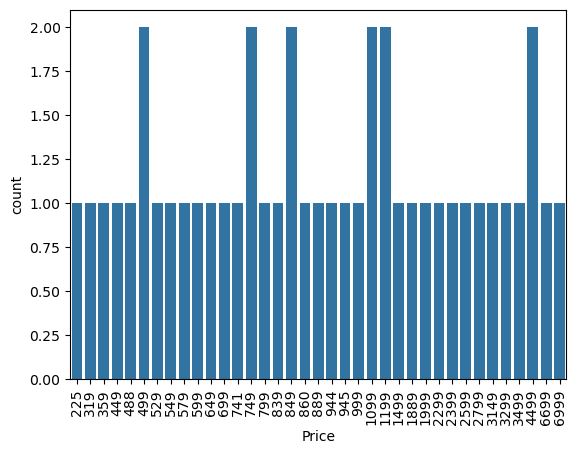

In [31]:
sns.countplot(x='Price',data=df)
plt.xticks(rotation=90)
plt.show()

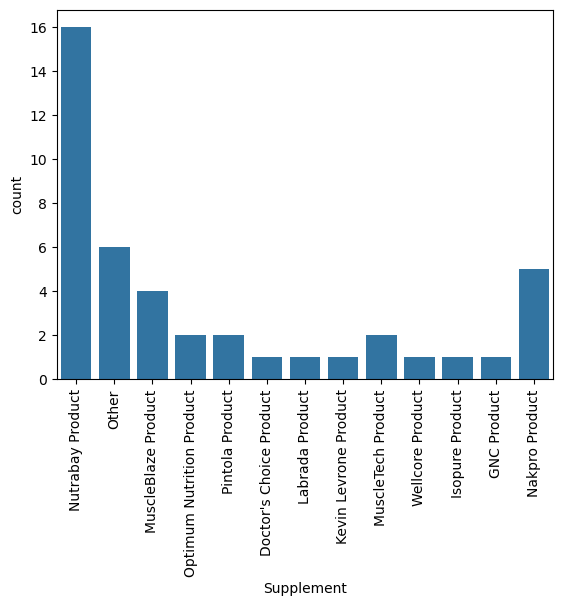

In [32]:
sns.countplot(x='Supplement',data=df)
plt.xticks(rotation=90)
plt.show()

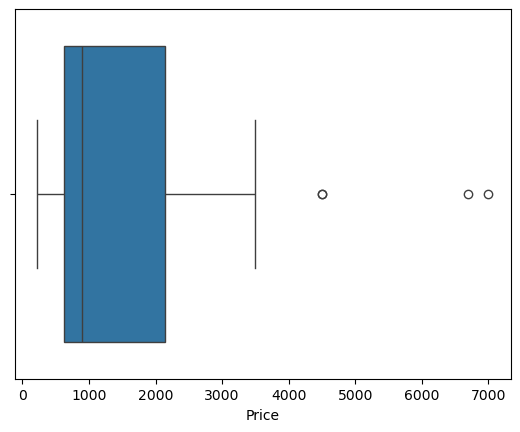

In [33]:
sns.boxplot(x='Price',data=df)
#plt.xticks(rotation=90)
plt.show()

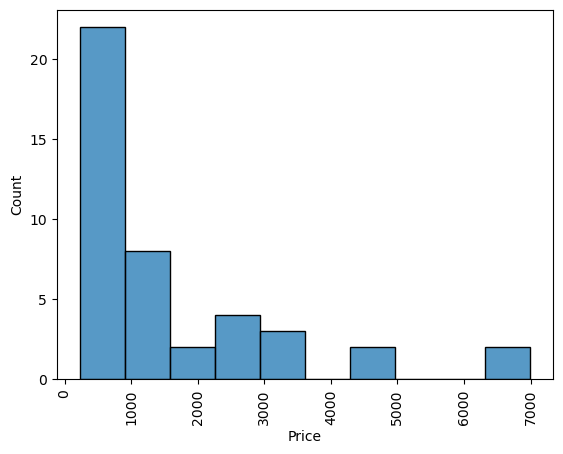

In [34]:
sns.histplot(x='Price',data=df,bins=10)
plt.xticks(rotation=90)
plt.show()

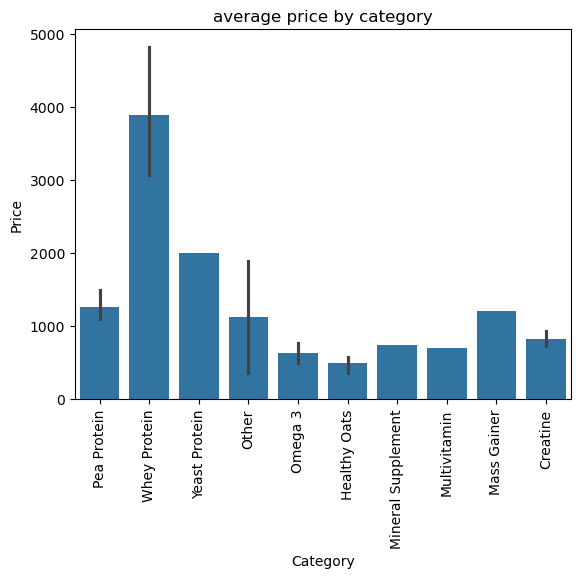

In [35]:
sns.barplot(x='Category',y='Price',data=df)
plt.xticks(rotation=90)
plt.title('average price by category')
plt.show()

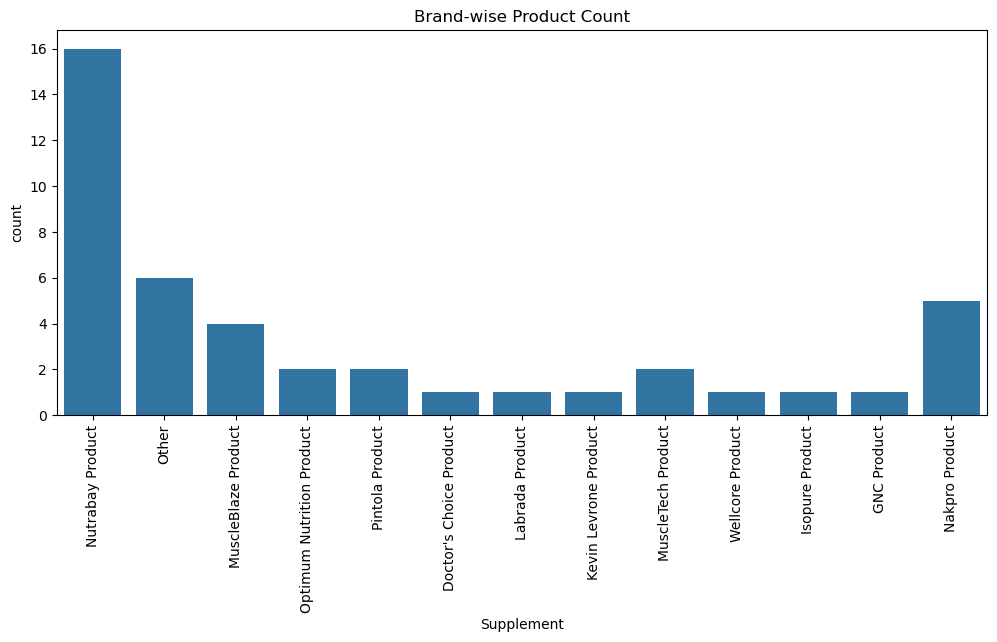

In [36]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Supplement',
    data=df
)

plt.xticks(rotation=90)

plt.title('Brand-wise Product Count')

plt.show()

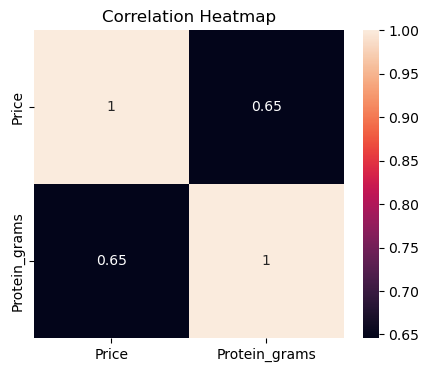

In [37]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

In [39]:
df.to_csv("nutrabay-python-analysis.csv", index=False)

In [ ]:
df.to_csv("nutrabay-python-analysis.csv", index=False)